In [1]:
# Run this in the first cell of your Colab notebook
!pip install qiskit qiskit-aer

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
import random

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 78.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.4 MB/s eta 0:00:00


In [2]:
def get_quantum_random_bit():
    """
    Creates a 1-qubit circuit, applies Hadamard gate to put it
    in superposition, then measures it. Returns 0 or 1.
    """
    # Create a circuit with 1 qubit and 1 classical bit
    qc = QuantumCircuit(1, 1)

    # Apply Hadamard gate → qubit enters superposition (50/50 state)
    qc.h(0)

    # Measure the qubit → collapses to 0 or 1 randomly
    qc.measure(0, 0)

    # Use Aer simulator (mimics a real quantum computer)
    simulator = AerSimulator()
    job = simulator.run(qc, shots=1)
    result = job.result()

    # Extract the measured bit
    counts = result.get_counts(qc)
    bit = int(list(counts.keys())[0])
    return bit

# Test it
print("Random quantum bit:", get_quantum_random_bit())

Random quantum bit: 1


In [3]:
def get_quantum_random_bits(n_bits=8):
    """
    Creates an n-qubit circuit. Each qubit goes through
    a Hadamard gate and is measured independently.
    Returns a bitstring like '10110010'.
    """
    qc = QuantumCircuit(n_bits, n_bits)

    # Apply Hadamard to ALL qubits at once
    for i in range(n_bits):
        qc.h(i)

    # Measure all qubits
    qc.measure(range(n_bits), range(n_bits))

    simulator = AerSimulator()
    job = simulator.run(qc, shots=1)
    result = job.result()

    counts = result.get_counts(qc)
    bitstring = list(counts.keys())[0]
    return bitstring

# Test it
bits = get_quantum_random_bits(8)
print(f"8-bit quantum random string: {bits}")
print(f"As integer (0-255): {int(bits, 2)}")

8-bit quantum random string: 11100011
As integer (0-255): 227


In [4]:
def quantum_random_int(min_val=0, max_val=255):
    """
    Generates a truly random integer between min_val and max_val
    using quantum randomness.
    """
    # Calculate how many bits we need
    range_size = max_val - min_val + 1
    n_bits = range_size.bit_length()

    # Keep generating until we get a value in range
    while True:
        bits = get_quantum_random_bits(n_bits)
        value = int(bits, 2)
        if value <= (max_val - min_val):
            return min_val + value

# Test it
print("Random number (1-100):", quantum_random_int(1, 100))
print("Random dice roll (1-6):", quantum_random_int(1, 6))

Random number (1-100): 87
Random dice roll (1-6): 5


In [5]:
def generate_quantum_key(key_length_bytes=16):
    """
    Generates a cryptographic key using quantum randomness.
    key_length_bytes=16 → 128-bit key (AES-128 standard)
    key_length_bytes=32 → 256-bit key (AES-256 standard)
    """
    key_bits = key_length_bytes * 8
    bits = get_quantum_random_bits(key_bits)

    # Convert bitstring to hexadecimal (standard key format)
    key_int = int(bits, 2)
    hex_key = format(key_int, f'0{key_length_bytes*2}x')
    return hex_key

# Generate a 128-bit key
key = generate_quantum_key(16)
print(f"Quantum-generated 128-bit encryption key:")
print(f"  {key}")
print(f"  Length: {len(key)*4} bits")

Quantum-generated 128-bit encryption key:
  52acf779ea4d2dfba7e8ca90a60eea40
  Length: 128 bits


In [6]:

def visualize_circuit(n_bits=4):
    """
    Draws the quantum circuit so you can see what's happening.
    """
    qc = QuantumCircuit(n_bits, n_bits)
    for i in range(n_bits):
        qc.h(i)
    qc.measure(range(n_bits), range(n_bits))

    print("Quantum Circuit Diagram:")
    print(qc.draw(output='text'))

visualize_circuit(4)

Quantum Circuit Diagram:
     ┌───┐┌─┐         
q_0: ┤ H ├┤M├─────────
     ├───┤└╥┘┌─┐      
q_1: ┤ H ├─╫─┤M├──────
     ├───┤ ║ └╥┘┌─┐   
q_2: ┤ H ├─╫──╫─┤M├───
     ├───┤ ║  ║ └╥┘┌─┐
q_3: ┤ H ├─╫──╫──╫─┤M├
     └───┘ ║  ║  ║ └╥┘
c: 4/══════╩══╩══╩══╩═
           0  1  2  3 


Generating quantum random numbers...
Generating classical random numbers...


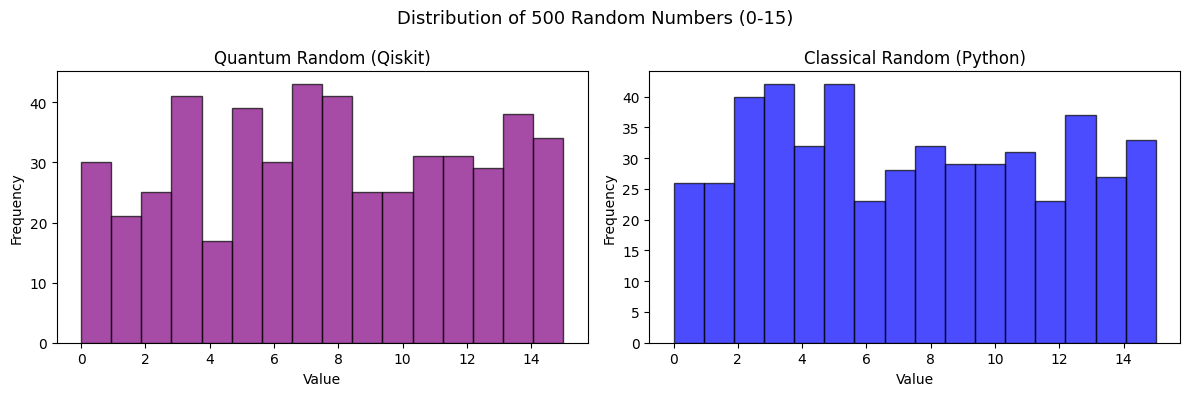

In [7]:
def compare_randomness(n_samples=1000):
    """
    Generates many random numbers and plots the distribution.
    A truly random source should produce a flat (uniform) distribution.
    """
    print("Generating quantum random numbers...")
    quantum_nums = [quantum_random_int(0, 15) for _ in range(n_samples)]

    print("Generating classical random numbers...")
    classical_nums = [random.randint(0, 15) for _ in range(n_samples)]

    # Plot both distributions
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.hist(quantum_nums, bins=16, color='purple', alpha=0.7, edgecolor='black')
    ax1.set_title('Quantum Random (Qiskit)')
    ax1.set_xlabel('Value')
    ax1.set_ylabel('Frequency')

    ax2.hist(classical_nums, bins=16, color='blue', alpha=0.7, edgecolor='black')
    ax2.set_title('Classical Random (Python)')
    ax2.set_xlabel('Value')
    ax2.set_ylabel('Frequency')

    plt.suptitle(f'Distribution of {n_samples} Random Numbers (0-15)', fontsize=13)
    plt.tight_layout()
    plt.savefig("randomness_comparison.png", dpi=150, bbox_inches='tight')
    plt.show()

compare_randomness(500)

In [8]:
def quantum_otp_encrypt(message: str) -> tuple:
    """
    Encrypts a message using a quantum-generated One-Time Pad.
    This is mathematically unbreakable if key is truly random.
    """
    # Convert message to bytes
    msg_bytes = message.encode('utf-8')
    n_bits_needed = len(msg_bytes) * 8

    # Generate quantum key (same length as message)
    key_bits = get_quantum_random_bits(n_bits_needed)
    key_int = int(key_bits, 2)

    # Convert key to bytes
    key_bytes = key_int.to_bytes(len(msg_bytes), byteorder='big')

    # XOR message with key → ciphertext
    ciphertext = bytes([m ^ k for m, k in zip(msg_bytes, key_bytes)])

    print(f"Original message : {message}")
    print(f"Quantum key (hex): {key_bytes.hex()}")
    print(f"Ciphertext (hex) : {ciphertext.hex()}")
    return ciphertext, key_bytes

def quantum_otp_decrypt(ciphertext: bytes, key_bytes: bytes) -> str:
    """Decrypts using the same key — XOR again."""
    decrypted = bytes([c ^ k for c, k in zip(ciphertext, key_bytes)])
    return decrypted.decode('utf-8')

# Test it
cipher, key = quantum_otp_encrypt("HELLO QUANTUM")
recovered = quantum_otp_decrypt(cipher, key)
print(f"Decrypted back   : {recovered}")

Original message : HELLO QUANTUM
Quantum key (hex): f52c6d58ca991390c46a9e24a9
Ciphertext (hex) : bd69211485b942c58524ca71e4
Decrypted back   : HELLO QUANTUM
